# RODM方法在OFPV系统的应用及优势
## 验证三种降维方法，斜入射波浪等情况的对比
## 铰接模式
## 不均匀波浪
## 其他形状的水弹性分析

In [18]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M

### 1. 计算SEREP数据

In [34]:
num_nodes = 793
wave_number = 145
direction = 180
node_position_params = (424, 6, 10)
# E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_145_direction180.nc
hydrodynamic_data_path = f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_{wave_number}_direction{direction}.nc"
structure_data_paths = {
    'mass': 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx',
    'stiffness': 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx'}

result_serep = DM_M.perform_RODM_reduce_order_model(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths,use_hydrostatic=True)

In [35]:
np.save(f"Serep_wl{wave_number}_d{direction}.npy", result_serep.reshape(793,5))

### 2. 计算Static\dynamic数据

In [20]:
# define parameters
num_nodes = 793 # 63 793
wave_number = 145
direction = 180
hydrodynamic_data_path = f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_{wave_number}_direction{direction}.nc"
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(424,6,10)
dataset = merge_complex_values(xr.open_dataset(hydrodynamic_data_path))

# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'#'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' #'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
# MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
MR_static, KR_static,T_static = SEREP.static_condensation(k, M, MasterDofs, SlaveDofs)
MR_dynamic, KR_dynamic, T_dynamic = SEREP.dynamic_condensation(k, M, MasterDofs, SlaveDofs)

def couple_equation(dataset, MR, KR, T, master_nodes, MasterDofs, SlaveDofs):
    # read hydrodynamic data
    omega = dataset.omega.values
    added_mass = dataset['added_mass'][0].values
    radiation_damping = dataset['radiation_damping'][0].values
    inertia_matrix = dataset['inertia_matrix'].values
    # hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
    # REDUCE THE MATRICES
    added_mass = SEREP.reduce_dofs(added_mass,10,[5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping,10,[5])
    # hyrostatic stiffness or fem spring stiffness
    # 1. choice hydrostatic stiffness
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,10,[5])
    # 2. choice fem spring stiffness
    # hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
    # hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,num_nodes,[5])
    # hydrostatic_stiffness = T.T @ hydrostatic_stiffness @ T

    inertia_matrix = SEREP.reduce_dofs(inertia_matrix,10,[5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)
    # F_w = F_w.reshape(10,5)[::-1].reshape(1,50)
    # Generate the system matrices
    mass = added_mass + MR
    damping = radiation_damping
    stiffness =  hydrostatic_stiffness + KR
    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)
    # Restore global displacement under disorder masterdofs and slavedofs
    global_displacement_disorder = T @ master_displacement

    master_displacement = master_displacement.reshape(10,5)[::-1].reshape(50,1)
    # # Reorder global displacement under order
    global_displacement_error = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

    global_displacement = DM_M.replace_master_with_global(master_displacement, global_displacement_error, master_nodes)
    
    return global_displacement

results_static = couple_equation(dataset, MR_static, KR_static, T_static, master_nodes, MasterDofs, SlaveDofs)
results_dynamic = couple_equation(dataset, MR_dynamic, KR_dynamic, T_dynamic, master_nodes, MasterDofs, SlaveDofs)


In [3]:
np.save(f"Static_wl{wave_number}_d{direction}.npy", results_static.reshape(793,5))
np.save(f"dynamic_wl{wave_number}_d{direction}.npy", results_dynamic.reshape(793,5))

In [ ]:
i = 2
# 处理位移结果
mid_static = results_static[367*5-5:427*5-5, :]
heave_static = abs(mid_static[i::5])

mid_dynamic = results_dynamic[367*5-5:427*5-5, :]
heave_dynamic = abs(mid_dynamic[i::5])

mid_serep = result_serep[367*5-5:427*5-5, :]
heave_serep = abs(mid_serep[i::5])

# 处理实验数据
from DM_Verify import process_exp_data

# x, y = process_exp_data("E:/phd/Code/DM-FEM2D/data/Experiment_300_60/exp_300.txt")
# y = np.array(y)

# 绘图
x1 = np.linspace(0, 1, 60)
import scienceplots
plt.style.use(['science', 'no-latex', 'ieee'])
plt.plot(x1, heave_serep, label="SEREP")
plt.plot(x1, heave_static[::-1], label="Static Condensation")
plt.plot(x1, heave_dynamic[::-1], label="Dynamic Condensation")
# plt.scatter(x, y, color='black', label="Model test", s=10)
plt.legend()
# plt.ylim(0, 0.1)  # 调整y轴坐标
plt.xlabel(r'$x/L$')
plt.ylabel(r'RAO ($m/m$)')
plt.show()

### 3.铰接模式的实现及对比,主要采用该代码进行实现 RODM_Hige_study_plan_a_2.ipynb

### 4.非均匀波浪场的计算，漂浮式光伏结构。在代码中实现，此处不再赘述。RODM_uneven_wave.ipynb

### 5.进行应力的计算

In [36]:
## 内力计算
import DM_Abaqus_inp as DM_inp
# Example usage
if __name__ == "__main__":
    num_nodes = 793
    degrees_of_freedom = 5
    result_expanded = np.load(f"E:\phd\Code\DM-FEM2D\FEM_Reduce\Serep_wl145_d180.npy")
    #result_expanded = np.sqrt(wind_displacement_root_mean_square) # replace this with your displacenmet matrix
    output_file_path = 'Boundary_Conditions_Job-1.inp'

    DM_inp.main_appied_boundary_conditions(num_nodes, degrees_of_freedom, result_expanded, output_file_path)
    input_new = 'Boundary_Conditions_Job-1_3_6.inp'
    DM_inp.modify_inp_file(output_file_path, input_new)

Boundary conditions INP file written to Boundary_Conditions_Job-1.inp


   Normalized X        Fu
0      0.000000  0.474529
1      0.002004  1.181006
2      0.004008  1.844834
3      0.006012  2.485539
4      0.008016  3.122644
   ndoe    all dof     only 3         R
0     1    67888.2   289622.0   13826.2
1     2    14553.7   176148.0   31366.7
2     3   950627.0   845328.0   69635.2
3     4   328968.0   376060.0  109055.0
4     5  1573080.0  1656790.0  146720.0


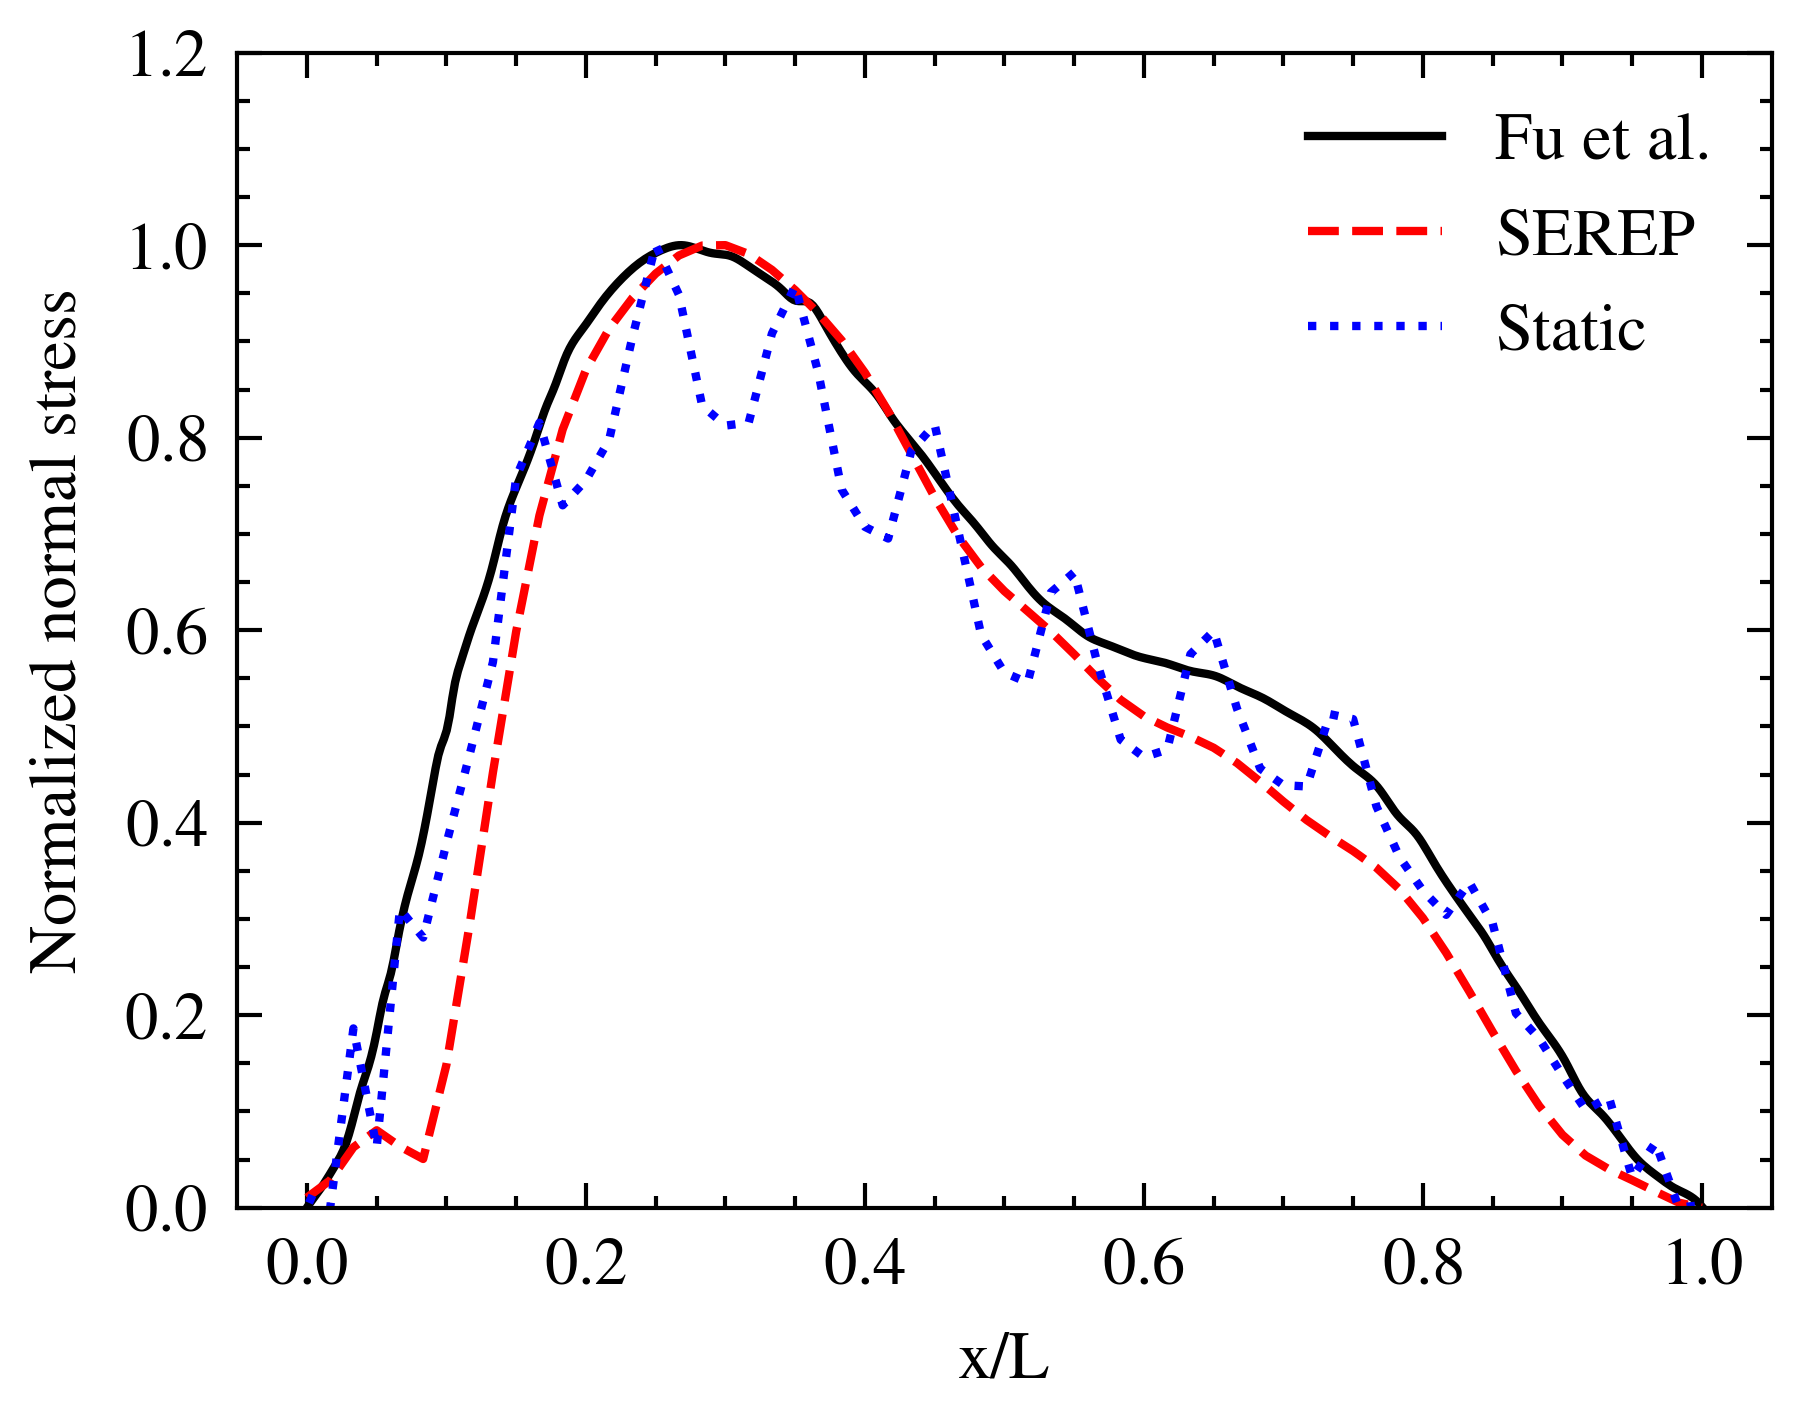

In [65]:
import pandas as pd  
import matplotlib.pyplot as plt  
import numpy as np  

# 读取 Excel 文件  
fu_data = pd.read_excel(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\force\FU.xlsx')  
force_data = pd.read_excel(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\RODM_Ad_data\force\force_compare.xlsx')  

# 初步查看数据  
print(fu_data.head())  
print(force_data.head())  

# 提取感兴趣的列并归一化（将数据范围变为 0-1）  
def normalize(column):  
    return (column - column.min()) / (column.max() - column.min())  

# 假定 FU 数据的横坐标为第一个列，纵坐标是目标列  
fu_x = normalize(fu_data.iloc[:, 0])  # 横坐标  
fu_y = normalize(fu_data.iloc[:, 1])  # Fu的值  

# 假定 force_compare 的每列皆为需要对比的数据列  
force_x = normalize(force_data.iloc[:, 0])  # 横坐标  
force_y_all = force_data.iloc[:, 1:]       # Force_compare中所有其他列  
force_y_normalized = force_y_all.apply(normalize)  # 对每列数据进行归一化  

# # 反转 R 数据 (假设 R 是 “force_compare” 的最后一列)  
# if 'R' in force_data.columns:  
#     force_y_normalized['R'] = 1 - force_y_normalized['R']  
serep_stress = np.array(force_y_normalized["R"])
static_stress_all = np.array(force_y_normalized["all dof"])
static_stress_3 = np.array(force_y_normalized["only 3"])
force_x  = np.linspace(0, 1, 61)
# 绘制 FU 数据  
plt.plot(fu_x, fu_y, label='Fu et al.')  
plt.plot(force_x, serep_stress[::-1], label='SEREP')
plt.plot(force_x, static_stress_all, label='Static')
# plt.plot(force_x, static_stress_3, label='Static 3', linestyle='-', color='black')

# 添加坐标轴标题  
plt.xlabel('x/L')  # 横坐标命名为 x/L  
plt.ylabel('Normalized normal stress')  # 纵坐标命名为归一化的结果  

plt.legend()  
plt.ylim(0, 1.2)  # 调整y轴坐标
plt.savefig("force_date.pdf", dpi=300)
# 显示图像  
plt.show()

In [48]:
for column in force_y_normalized.columns:  
    print(column)

all dof
only 3
R


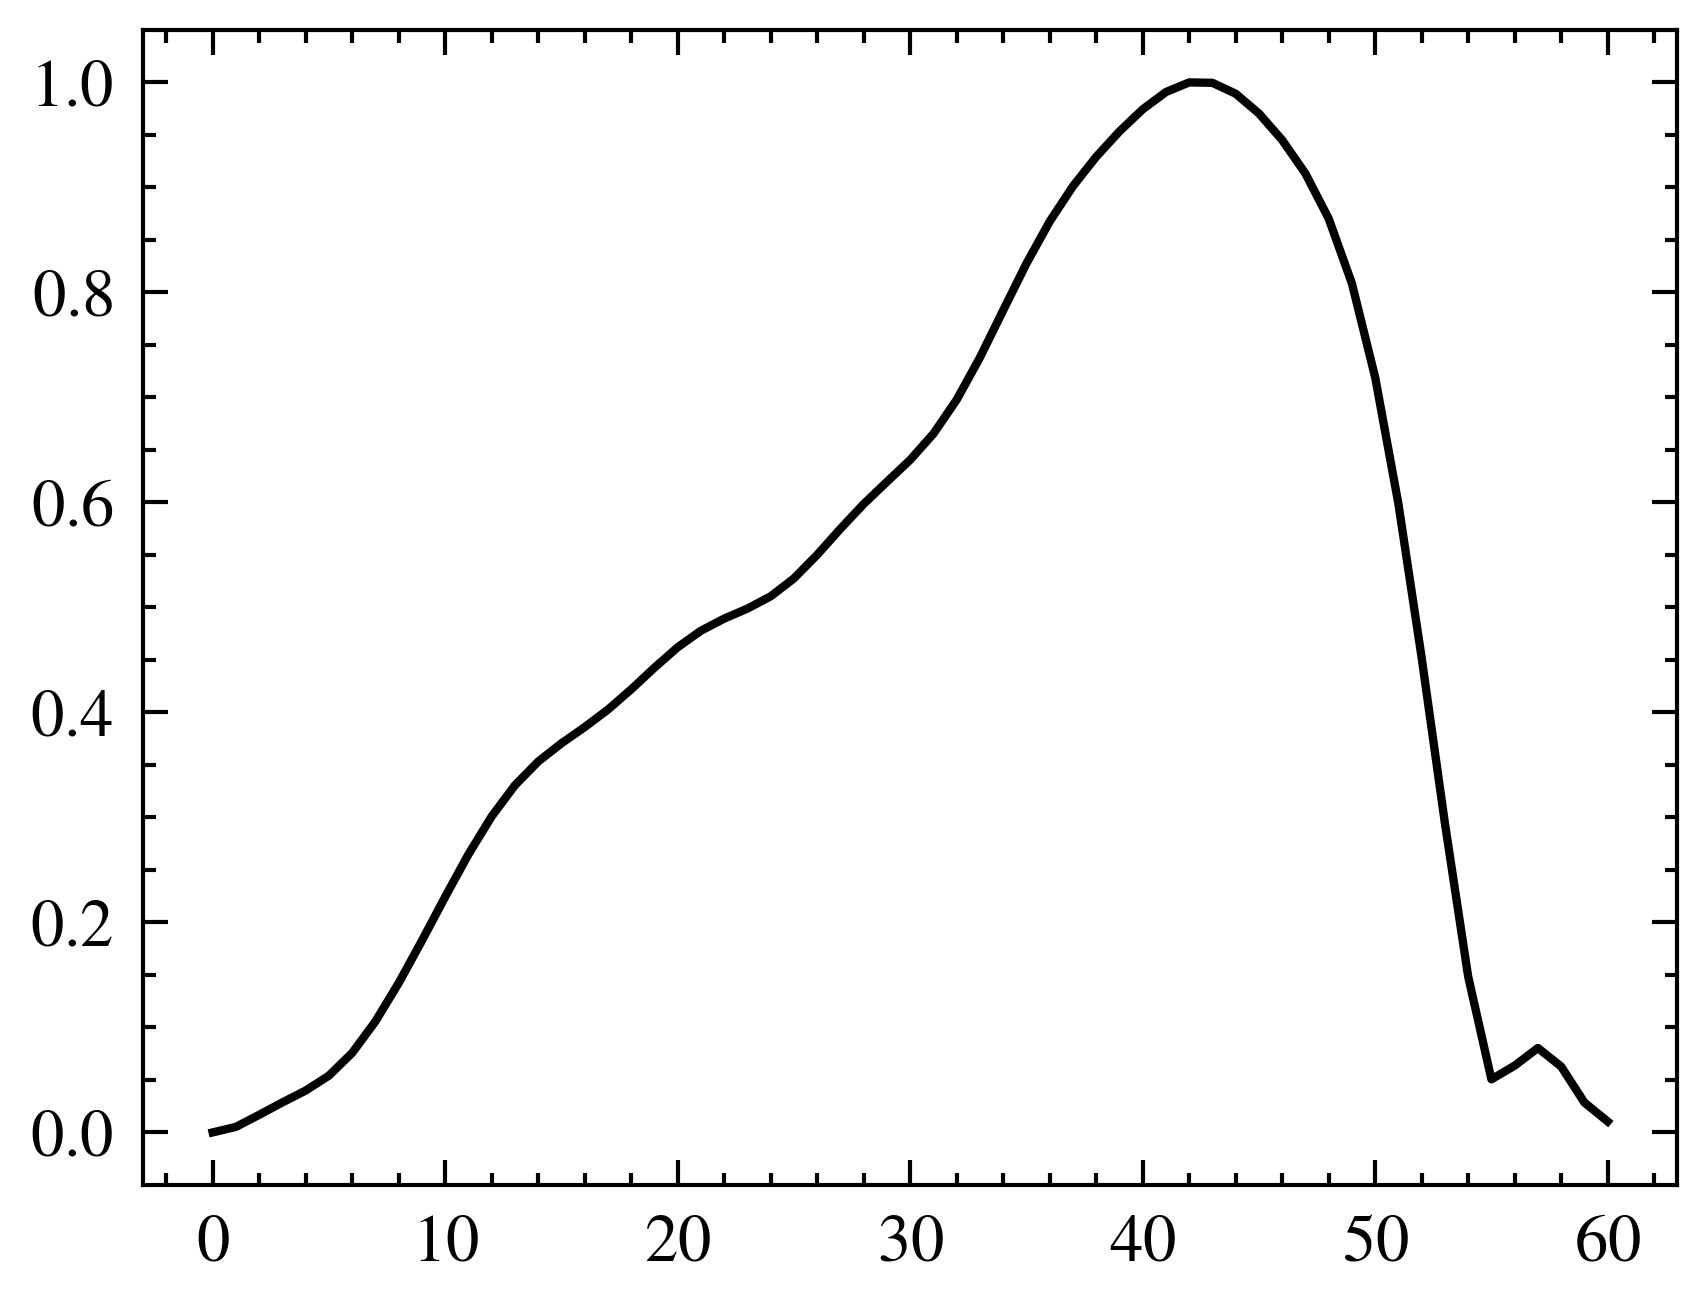

In [51]:
plt.plot(np.array(force_y_normalized["R"]))